# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [97]:
import pandas as pd
from sqlalchemy import create_engine
db_config = {"user": 'praktikum_student', 
             'pwd': 'Sdf4$2;d-d30pp', 
              'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net', 
               'port':'6432',
                'db': 'data-analyst-afisha' }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 
engine = create_engine(connection_string)
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk))::INT AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id = e.event_id
JOIN afisha.city c ON e.city_id = c.city_id
JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''
df = pd.read_sql_query(query, con = engine)

**Данные успешно выгружены**

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [98]:
display(df)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [100]:
df.describe(percentiles=([0.25,0.50,0.75,0.90,0.99]))

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611,290611,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,2024-09-01 22:36:38.741272,2024-09-02 13:31:19.397731,625.584360,2.754311,3.222381,438019.834992
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,2024-07-30 00:00:00,2024-07-30 11:53:37.500000,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,2024-09-12 00:00:00,2024-09-12 14:02:10,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,2024-10-09 00:00:00,2024-10-09 15:57:55.500000,810.130000,4.000000,1.000000,546287.000000
90%,7.786443e+06,2024-10-23 00:00:00,2024-10-23 21:59:48,1323.070000,4.000000,7.000000,567143.000000
99%,8.566888e+06,2024-10-31 00:00:00,2024-10-31 21:32:27.800000,4003.133000,6.000000,63.000000,589623.000000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,81174.540000,57.000000,148.000000,592325.000000
std,2.497551e+06,NaN,NaN,1227.693064,1.170620,11.350509,147423.078841


**Выводы по первичному общему анализу**
- В данных представлена информация о 290610 заказах, параметров заказа (колонок) = 15
- В данных нет пропусков
- Данные представлены с 1 июня 2024 года по 31 октября 2024 года (5 месяцев), также есть информация о времени совершения каждого заказа
- **В дальнейшем важно обратить внимание на параметр выручки (revenue), поскольку он имеет отрицательные значения, а также аномально высокие значения**
- **Также в дальнейщем важно обратить внимание на параметр количечества купленных билетов на наличие аномалий (максимальное количество = 57 при 99 процентиле = 6)**

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [101]:
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
display(final_tickets_tenge_df)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [102]:
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

In [103]:
df = df.merge(final_tickets_tenge_df, left_on= 'order_dt', right_on= 'data')
df['revenue_rub'] = df.apply(lambda x: x['revenue']*x['curs']/100 if x['currency_code'] == 'kzt' else x['revenue'], axis = 1)

In [104]:
df.drop(columns=['nominal', 'curs', 'cdx', 'data'], inplace=True)

In [105]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [106]:
## Проверяем на наличие пропусков
df.isnull().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

**Вывод: пропуски только в столбце days_since_prev (21933)**

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [108]:
## При первичном просмотре увидели, что данные находятся в правильных типах. Однако для некоторых столбцов можно сэкономить память
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='integer') ## есть путстые, поэтому не сработало
df['currency_code'] = df['currency_code'].astype('category')
df['device_type_canonical'] = df['device_type_canonical'].astype('category')
df['event_type_main'] = df['event_type_main'].astype('category')
df['order_dt'] = df['order_dt'].astype('datetime64[s]')
df['order_ts'] = df['order_ts'].astype('datetime64[s]')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                290611 non-null  str          
 1   device_type_canonical  290611 non-null  category     
 2   order_id               290611 non-null  int64        
 3   order_dt               290611 non-null  datetime64[s]
 4   order_ts               290611 non-null  datetime64[s]
 5   currency_code          290611 non-null  category     
 6   revenue                290611 non-null  float64      
 7   tickets_count          290611 non-null  int8         
 8   days_since_prev        268678 non-null  float64      
 9   event_id               290611 non-null  int64        
 10  event_name             290611 non-null  str          
 11  event_type_main        290611 non-null  category     
 12  service_name           290611 non-null  str          
 13  region_nam

#### Проводим анализ данных по ключевым номинальным столбцам 

In [109]:
print(f" Уникальные значения типа устройства - {df['device_type_canonical'].unique().tolist()}")

 Уникальные значения типа устройства - ['mobile', 'desktop']


In [110]:
print(f" Уникальные значения типа валюты - {df['currency_code'].unique().tolist()}")

 Уникальные значения типа валюты - ['rub', 'kzt']


In [111]:
print(f" Уникальные значения типа мероприятия - {df['event_type_main'].unique().tolist()}")

 Уникальные значения типа мероприятия - ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']


- **Заметим, что в типе мероприятия есть категория "другое"**

In [112]:
print(f" Уникальные значения имя мероприятия - {df['event_name'].unique().tolist()}")
print(f"Количество уникальных значений - {df['event_name'].nunique()} ")

 Уникальные значения имя мероприятия - ['f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad', '40efeb04-81b7-4135-b41f-708ff00cc64c', '01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca', '2f638715-8844-466c-b43f-378a627c419f', '10d805d3-9809-4d8a-834e-225b7d03f95d', '9cc55c15-4375-4129-9979-3129688ba1b4', '2f98d69f-4e60-4ffc-8f16-e539383526b1', '0d876e01-851e-458b-ba61-753e0e0c4063', 'ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1', '11be386f-7cb7-4aa1-a8e4-ba73a29c1af2', 'bac91ae0-de5d-4d88-8690-6343144b20dc', '102fa659-6ca3-4a78-a0a4-20a0339679b5', 'fcc6c52f-3a46-4d22-8a54-8a7812065aef', '0f8e05fc-56be-4bc7-b775-e3cd61ae6fe4', 'e252d33a-2394-44b8-b11d-f0709a6f0260', 'ba2dbc92-2c6e-43cb-ae5a-ee5e1c5e4a14', 'd13f8352-4f10-41e4-b19d-cde15b4d615b', '990b8b09-85d8-4ffb-9074-ab5303cd3c33', '56d38bb0-bc2b-4b8f-a9a2-be9a90084e38', '763161c7-4411-4b4c-86de-8ca8b36d7f1f', 'dff567b7-11a5-4c4c-b223-70c8ab7efd15', 'fb635bfa-3a1c-4d7b-8759-fb7dac77fb6f', '9ee85cae-24ba-4360-90ef-974047791edf', '1051e90b-588a-4355-8dc6-bc20887f83d7', 

In [113]:
print(f" Уникальные значения имя сервиса- {df['service_name'].unique().tolist()}")
print(f"Количество уникальных значений имя сервиса- {df['service_name'].nunique()}")

 Уникальные значения имя сервиса- ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная', 'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки', 'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко', 'Билет по телефону', 'Выступления.ру', 'Росбилет', 'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет', 'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ', 'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет', 'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете']
Количество уникальных значений имя сервиса- 36


In [114]:
print(f" Уникальные значения имя региона- {df['region_name'].unique().tolist()}")
print(f"Количество уникальных значений имя региона- {df['region_name'].nunique()}")

 Уникальные значения имя региона- ['Каменевский регион', 'Североярская область', 'Озернинский край', 'Лугоградская область', 'Поленовский край', 'Широковская область', 'Медовская область', 'Златопольский округ', 'Малиновоярский округ', 'Яблоневская область', 'Ветренский регион', 'Боровлянский край', 'Крутоводская область', 'Ягодиновская область', 'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область', 'Горицветская область', 'Речиновская область', 'Травиницкий округ', 'Сосновская область', 'Серебринская область', 'Травяная область', 'Каменноярский край', 'Солнечноземская область', 'Светополянский округ', 'Заречная область', 'Ручейковский край', 'Глиногорская область', 'Тепляковская область', 'Каменноозёрный край', 'Солнечнореченская область', 'Зоринский регион', 'Берёзовская область', 'Лесостепной край', 'Малиновая область', 'Синегорский регион', 'Луговая область', 'Шанырский регион', 'Каменополянский округ', 'Речицкая область', 'Горностепной регион', 'Речицкий регион', 'Зо

In [115]:
print(f" Уникальные значения имя города- {df['city_name'].unique().tolist()}")
print(f"Количество уникальных значений имя города- {df['city_name'].nunique()}")

 Уникальные значения имя города- ['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск', 'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай', 'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич', 'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск', 'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск', 'Луговаярово', 'Дальнополин', 'Ягодиновка', 'Солчелуг', 'Озёрчане', 'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград', 'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск', 'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск', 'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк', 'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск', 'Радужанов', 'Глиногорь', 'Каменосветск', 'Родниковск', 'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье', 'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино', 'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов', 'Ордасай', 'Теплоозёрск', 'Чистогорье', 'Ручейный', 'Островярово', 'Я

#### Проводим анализ данных по ключевым числовым столбцам

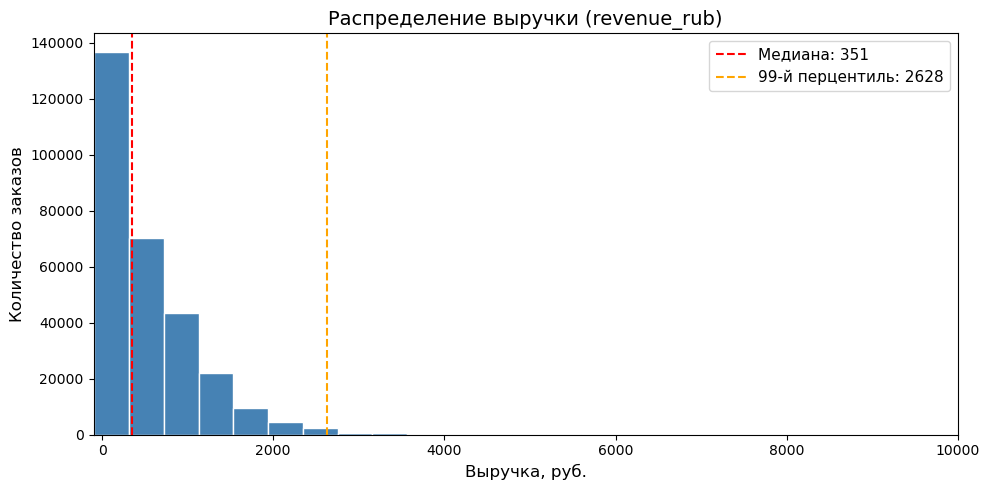

In [116]:
import matplotlib.pyplot as plt
# Гистограмма revenue_rub
plt.figure(figsize=(10, 5))
plt.hist(df['revenue_rub'], bins=200, color='steelblue', edgecolor='white')
plt.title('Распределение выручки (revenue_rub)', fontsize=14)
plt.xlabel('Выручка, руб.', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.xlim(-100,10000)
plt.axvline(df['revenue_rub'].median(), color='red', linestyle='--', label=f'Медиана: {df["revenue_rub"].median():.0f}')
plt.axvline(df['revenue_rub'].quantile(0.99), color='orange', linestyle='--', label=f'99-й перцентиль: {df["revenue_rub"].quantile(0.99):.0f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


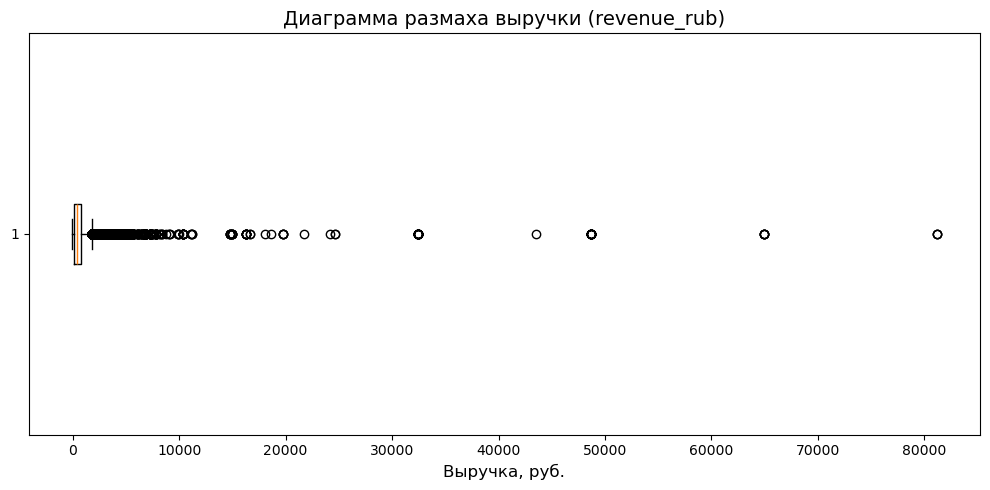

In [117]:
# Boxplot revenue_rub
plt.figure(figsize=(10, 5))
plt.boxplot(df['revenue_rub'], vert=False, showfliers=True)
plt.title('Диаграмма размаха выручки (revenue_rub)', fontsize=14)
plt.xlabel('Выручка, руб.', fontsize=12)
plt.tight_layout()
plt.show()


- **Выводы по графикам: видны выбросы выручки. Фильтруем данные по 99 перцентилю**

In [118]:
p99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= p99]
print(f'Отфильтровано строк: {290611 - len(df)}')

Отфильтровано строк: 2825


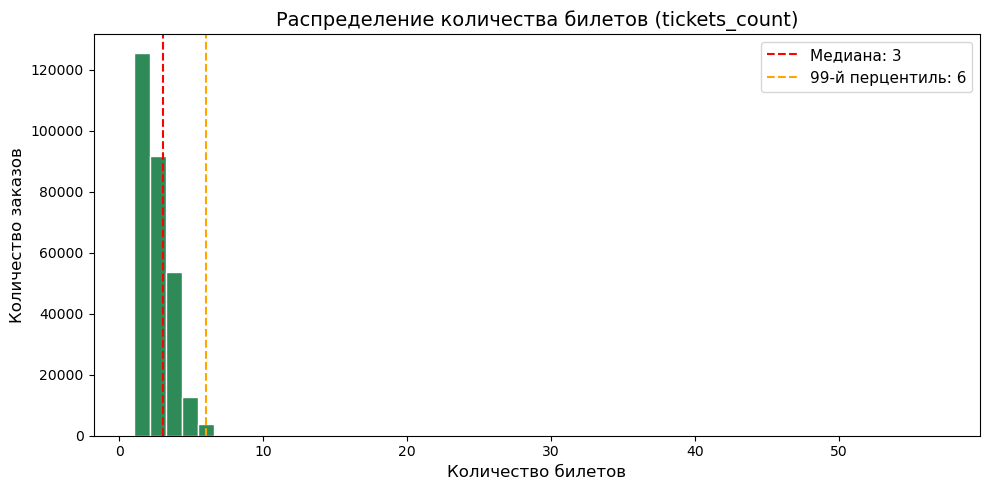

In [119]:
plt.figure(figsize=(10, 5))
plt.hist(df['tickets_count'], bins=50, color='seagreen', edgecolor='white')
plt.title('Распределение количества билетов (tickets_count)', fontsize=14)
plt.xlabel('Количество билетов', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.axvline(df['tickets_count'].median(), color='red', linestyle='--', label=f'Медиана: {df["tickets_count"].median():.0f}')
plt.axvline(df['tickets_count'].quantile(0.99), color='orange', linestyle='--', label=f'99-й перцентиль: {df["tickets_count"].quantile(0.99):.0f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


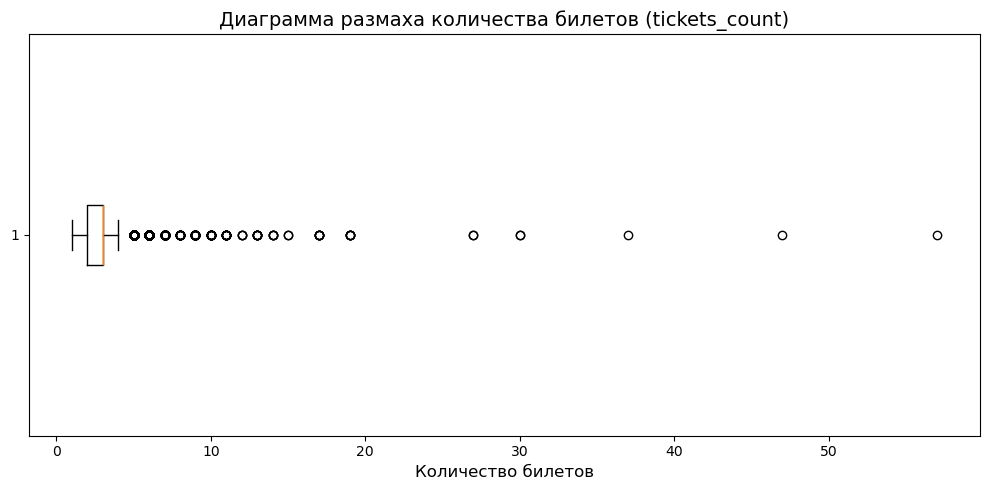

In [120]:
# Boxplot tickets_count
plt.figure(figsize=(10, 5))
plt.boxplot(df['tickets_count'], vert=False)
plt.title('Диаграмма размаха количества билетов (tickets_count)', fontsize=14)
plt.xlabel('Количество билетов', fontsize=12)
plt.tight_layout()
plt.show()

- **Вывод по графикам: по данным диаграммы размаха также видны аномальные значения. Однако оставим их для дальнейшего анализа, поскольку возможна групповая покупка билетов на мероприятия (что и вызвало более 6 покупок билетов)**

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [121]:
df = df.sort_values(by = 'order_ts', ascending= True, axis= 0)

In [122]:
user_profile = df.groupby('user_id', as_index= False).agg(
    first_order_dt = ('order_dt', 'min'),
    last_order_dt = ('order_dt', 'max'),
    first_device = ('device_type_canonical', 'first'),
    first_region = ('region_name', 'first'), 
    first_service_name = ('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders = ('order_id', 'count'), 
    mean_rub_revenue = ('revenue_rub', 'mean'),
    mean_tickets_number = ('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
)

In [123]:
user_profile['is_two'] = user_profile['total_orders'].apply(lambda x: True if x>=2 else False)
user_profile['is_five'] = user_profile['total_orders'].apply(lambda x: True if x>=5 else False)

In [124]:
display(user_profile)

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service_name,first_event_type,total_orders,mean_rub_revenue,mean_tickets_number,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.000,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.000,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21849,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13.375,True,True
21850,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74.000,True,False
21851,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4.125,True,True
21852,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaN,False,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [125]:
print(f"Всего пользователей: {len(user_profile)}")
print(f"Средняя выручка с заказа: {user_profile['mean_rub_revenue'].mean():.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {user_profile['is_two'].mean():.2%}")
print(f"Доля пользователей с 5+ заказами: {user_profile['is_five'].mean():.2%}")

Всего пользователей: 21854
Средняя выручка с заказа: 544.40 руб.
Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%


In [126]:
user_profile[['total_orders', 'mean_tickets_number', 'avg_days_since_prev']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)

,total_orders,mean_tickets_number,avg_days_since_prev
count,21854.000000,21854.000000,13521.000000
mean,13.168573,2.743129,15.836109
std,121.674800,0.913080,22.297926
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.076923,20.400000
95%,31.350000,4.000000,61.500000
99%,152.000000,5.000000,112.000000
max,10181.000000,11.000000,148.000000


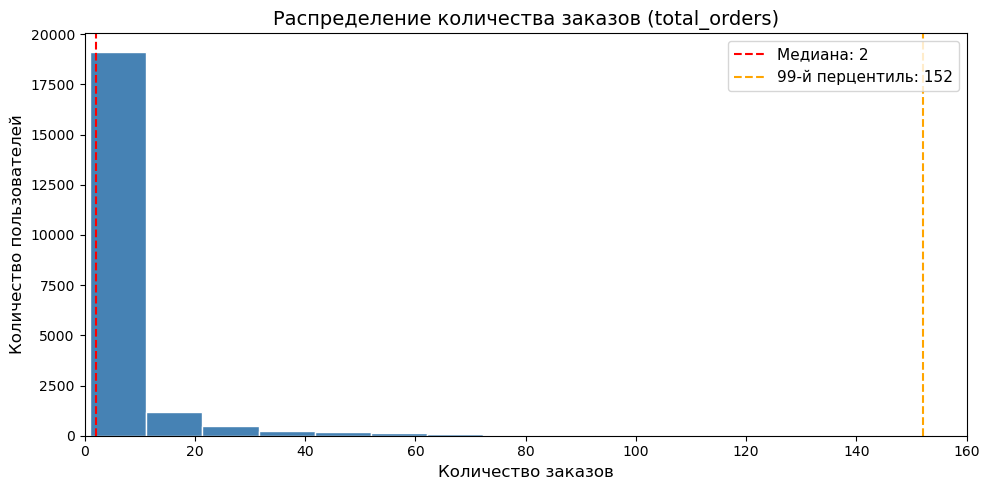

In [127]:
# Гистограмма total_orders
plt.figure(figsize=(10, 5))
plt.hist(user_profile['total_orders'], bins=1000, color='steelblue', edgecolor='white')
plt.title('Распределение количества заказов (total_orders)', fontsize=14)
plt.xlabel('Количество заказов', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xlim(0, 160)
plt.axvline(user_profile['total_orders'].median(), color='red', linestyle='--', label=f'Медиана: {user_profile["total_orders"].median():.0f}')
plt.axvline(user_profile['total_orders'].quantile(0.99), color='orange', linestyle='--', label=f'99-й перцентиль: {user_profile["total_orders"].quantile(0.99):.0f}')
plt.legend(fontsize=11,loc='upper right' )
plt.tight_layout()
plt.show()

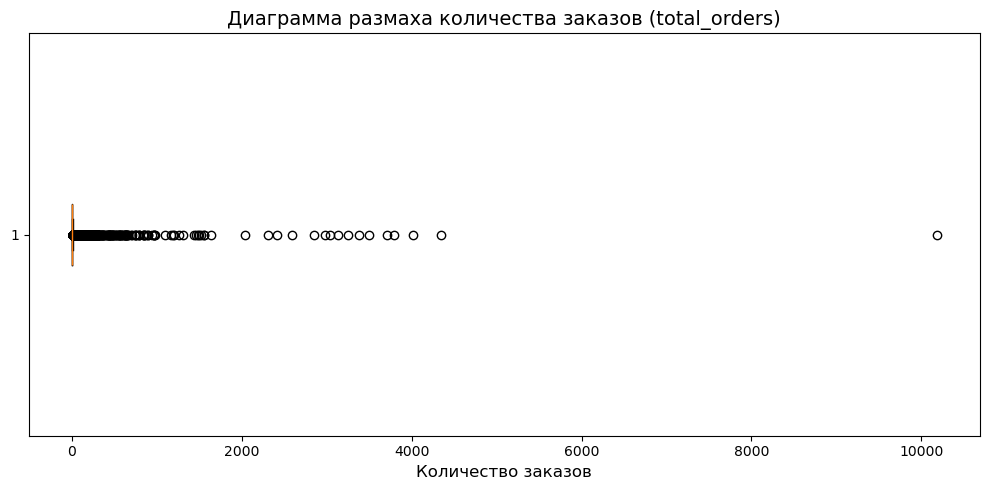

In [128]:
# Боксплот total_orders
plt.figure(figsize=(10, 5))
plt.boxplot(user_profile['total_orders'], vert=False)
plt.title('Диаграмма размаха количества заказов (total_orders)', fontsize=14)
plt.xlabel('Количество заказов', fontsize=12)
plt.tight_layout()
plt.show()

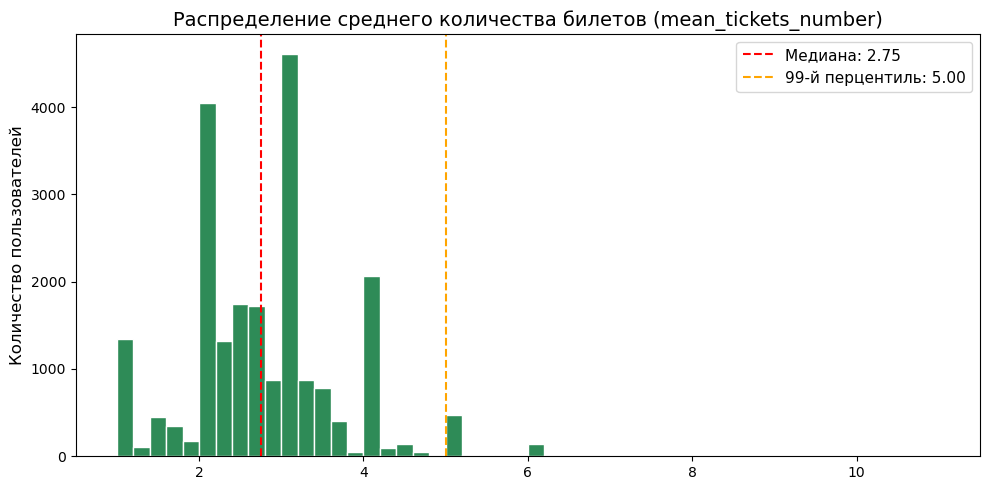

In [129]:
# Гистограмма mean_tickets_number
plt.figure(figsize=(10, 5))
plt.hist(user_profile['mean_tickets_number'], bins=50, color='seagreen', edgecolor='white')
plt.title('Распределение среднего количества билетов (mean_tickets_number)', fontsize=14)
plt.ylabel('Количество пользователей', fontsize=12)
plt.axvline(user_profile['mean_tickets_number'].median(), color='red', linestyle='--', label=f'Медиана: {user_profile["mean_tickets_number"].median():.2f}')
plt.axvline(user_profile['mean_tickets_number'].quantile(0.99), color='orange', linestyle='--', label=f'99-й перцентиль: {user_profile["mean_tickets_number"].quantile(0.99):.2f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

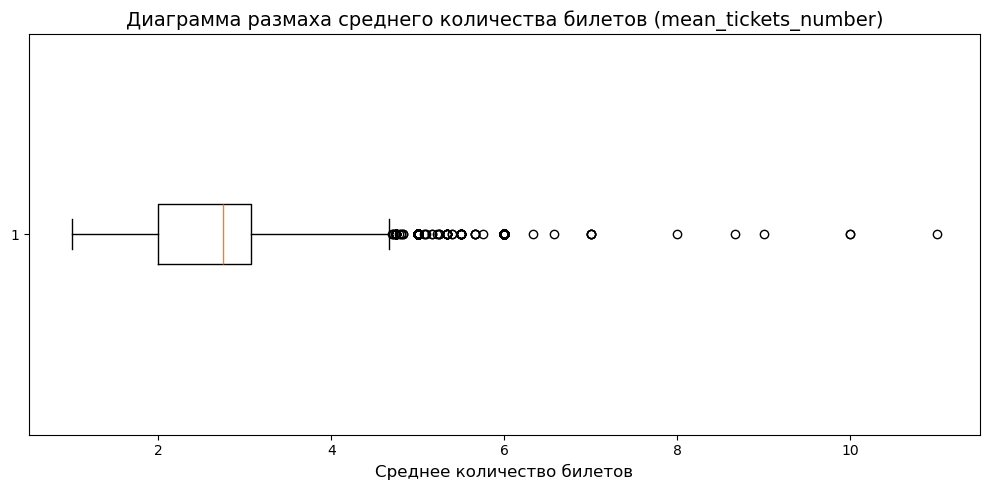

In [130]:
# Боксплот mean_tickets_number
plt.figure(figsize=(10, 5))
plt.boxplot(user_profile['mean_tickets_number'], vert=False)
plt.title('Диаграмма размаха среднего количества билетов (mean_tickets_number)', fontsize=14)
plt.xlabel('Среднее количество билетов', fontsize=12)
plt.tight_layout()
plt.show()

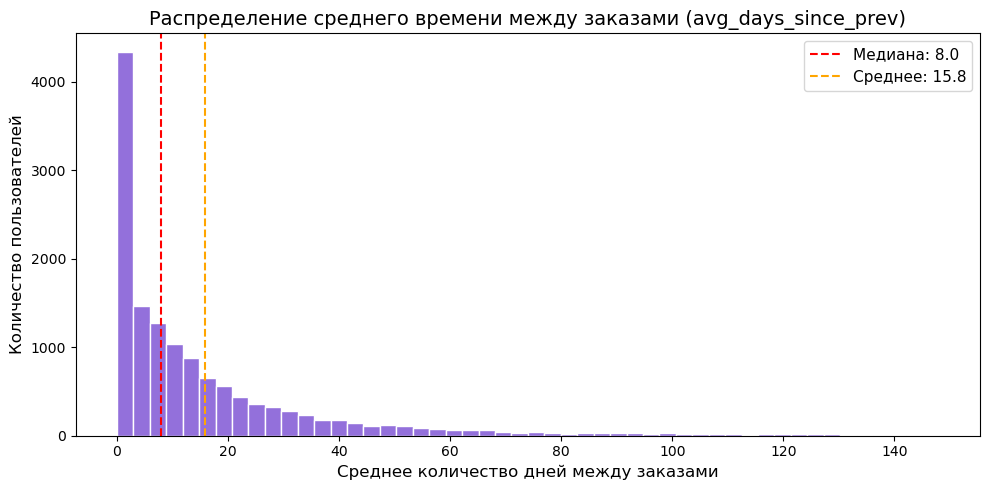

In [131]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['avg_days_since_prev'], bins=50, color='mediumpurple', edgecolor='white')
plt.title('Распределение среднего времени между заказами (avg_days_since_prev)', fontsize=14)
plt.xlabel('Среднее количество дней между заказами', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.axvline(user_profile['avg_days_since_prev'].median(), color='red', linestyle='--', 
            label=f'Медиана: {user_profile["avg_days_since_prev"].median():.1f}')
plt.axvline(user_profile['avg_days_since_prev'].mean(), color='orange', linestyle='--', 
            label=f'Среднее: {user_profile["avg_days_since_prev"].mean():.1f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Выводы по анализу профилей пользователей

#### Базовые метрики
- Всего пользователей в выборке: **21 854**
- Средняя выручка с заказа: **544.40 руб.**
- Доля пользователей с 2+ заказами: **61.71%**
- Доля пользователей с 5+ заказами: **29.01%**

#### Анализ распределений

**`total_orders` (количество заказов):**
- Медиана = 2, 75% пользователей совершили до 5 заказов — типичное поведение
- Максимум = 10 181 заказ — аномально высокое значение, вероятно боты или тестовые аккаунты
- 99-й перцентиль = 152 — всё что выше считаем выбросом
- **Решение:** отфильтровать пользователей с `total_orders > 152`

**`mean_tickets_number` (среднее количество билетов):**
- Медиана = 2.75, основная масса от 1 до 5 билетов — соответствует реальному поведению (поход вдвоём, семьёй)
- Единичные значения до 11 билетов объяснимы (корпоратив, большая группа)
- **Решение:** оставить без фильтрации — выбросы не критичны

**`avg_days_since_prev` (среднее время между заказами):**
- Медиана = 8 дней, среднее = 15.8 дней — среднее почти в 2 раза больше медианы,
  что говорит о скошенности распределения вправо
- Стандартное отклонение = 22.3 при медиане 8 — большой разброс
- Максимум = 148 дней — некоторые пользователи возвращаются очень редко
- Однако гистограмма показывает **равномерное убывание** без пустых интервалов —
  это естественное поведение пользователей, а не аномалии
- **Решение:** оставить без фильтрации — распределение отражает реальную 
  картину активности: большинство возвращается быстро, меньшинство — редко


In [132]:
p99_orders = user_profile['total_orders'].quantile(0.99)

before = len(user_profile)
user_profile = user_profile[user_profile['total_orders'] <= p99_orders]
after = len(user_profile)

print(f'Отфильтровано пользователей: {before - after} ({(before - after) / before:.2%})')
print(f'Осталось пользователей: {after}')

Отфильтровано пользователей: 216 (0.99%)
Осталось пользователей: 21638


#### Фильтрация
После фильтрации `total_orders` по 99-му перцентилю (≤ 152)
отсеяно **216 пользователей (0.99%)** — данные практически не изменились по объёму.
Осталось **21 638 пользователей**.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [133]:
def segment_stats(col):
    stats = user_profile.groupby(col, as_index= False).agg(
        users_count = ('user_id', 'count'))
    stats['share'] = stats['users_count'] / stats['users_count'].sum()
    return stats.sort_values('users_count', ascending=False)


In [134]:
print('Тип мероприятия')
display(segment_stats('first_event_type'))

Тип мероприятия


,first_event_type,users_count,share
2,концерты,9560,0.441815
1,другое,5426,0.250763
5,театр,4239,0.195905
4,стендап,1110,0.051299
3,спорт,794,0.036695
0,выставки,414,0.019133
6,ёлки,95,0.004390


In [135]:
print('Тип устройства')
display(segment_stats('first_device'))

Тип устройства


,first_device,users_count,share
1,mobile,17924,0.828358
0,desktop,3714,0.171642


In [136]:
print('Регион (топ-10)')
display(segment_stats('first_region').head(10))

Регион (топ-10)


,first_region,users_count,share
23,Каменевский регион,7085,0.327433
60,Североярская область,3767,0.174092
77,Широковская область,1224,0.056567
45,Озернинский край,675,0.031195
41,Малиновоярский округ,525,0.024263
76,Шанырский регион,500,0.023107
74,Травяная область,488,0.022553
57,Светополянский округ,457,0.021120
52,Речиновская область,440,0.020335
78,Яблоневская область,411,0.018994


In [137]:
print('Билетный оператор (топ-10)')
display(segment_stats('first_service_name').head(10))

Билетный оператор (топ-10)


,first_service_name,users_count,share
3,Билеты без проблем,5186,0.239671
22,Мой билет,2969,0.137212
19,Лови билет!,2809,0.129818
4,Билеты в руки,2559,0.118264
23,Облачко,2177,0.100610
7,Весь в билетах,1285,0.059386
20,Лучшие билеты,1184,0.054719
24,Прачечная,583,0.026943
17,Край билетов,454,0.020982
12,Дом культуры,356,0.016453


##### Делаем визуализации по полученным сегментам

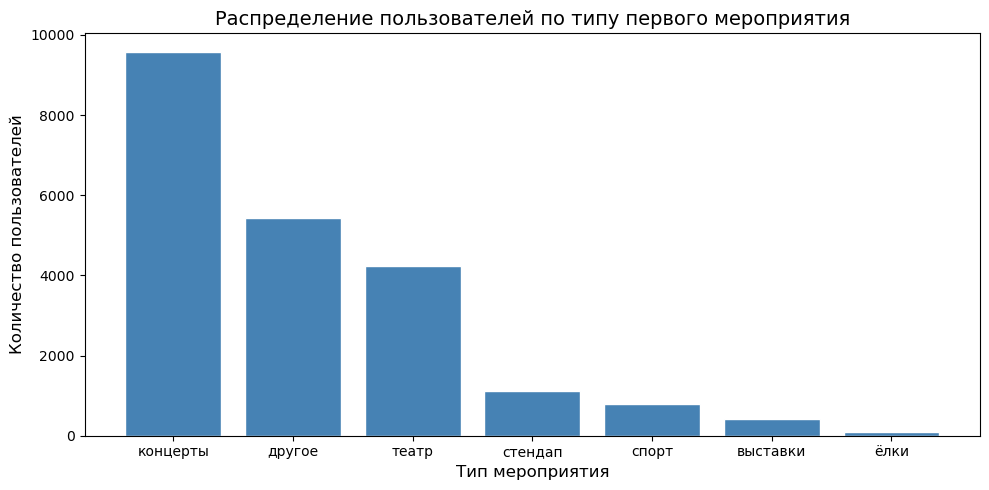

In [138]:
# Тип мероприятия
event_stats = segment_stats('first_event_type')
plt.figure(figsize=(10, 5))
plt.bar(event_stats['first_event_type'], event_stats['users_count'], color='steelblue', edgecolor='white')
plt.title('Распределение пользователей по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.tight_layout()
plt.show()

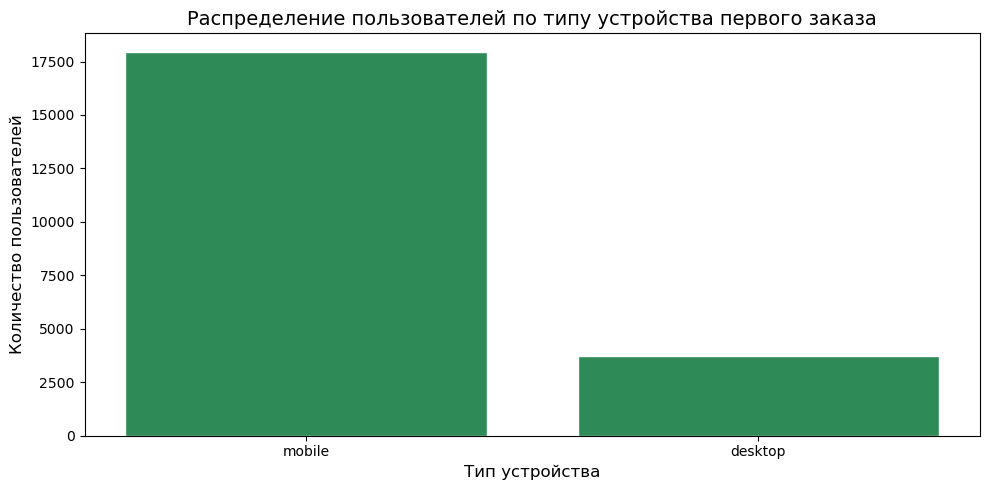

In [139]:
# Тип устройства
device_stats = segment_stats('first_device')
plt.figure(figsize=(10, 5))
plt.bar(device_stats['first_device'], device_stats['users_count'], color='seagreen', edgecolor='white')
plt.title('Распределение пользователей по типу устройства первого заказа', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.tight_layout()
plt.show()


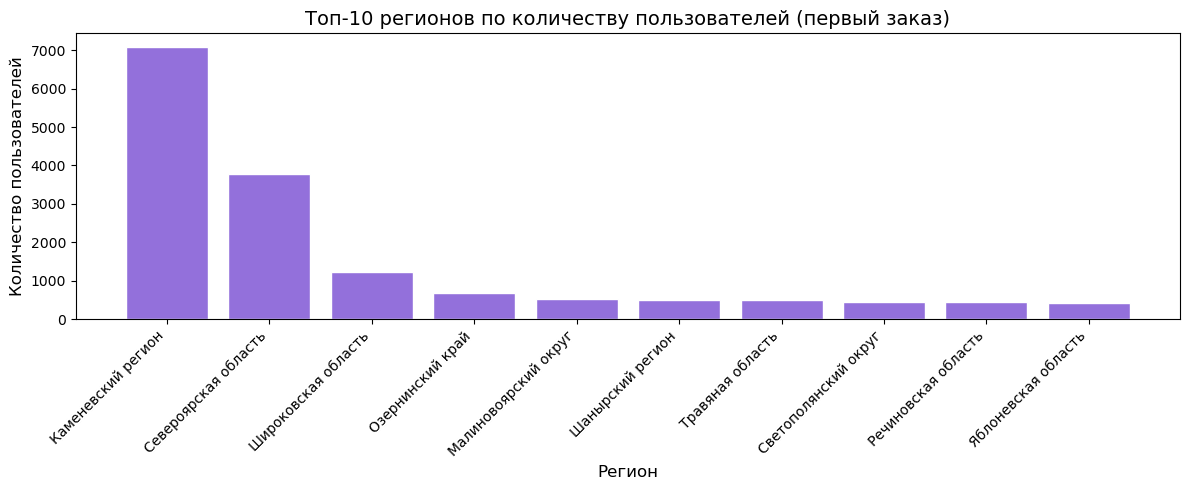

In [140]:
# Регион (топ-10)
region_stats = segment_stats('first_region').head(10)
plt.figure(figsize=(12, 5))
plt.bar(region_stats['first_region'], region_stats['users_count'], color='mediumpurple', edgecolor='white')
plt.title('Топ-10 регионов по количеству пользователей (первый заказ)', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

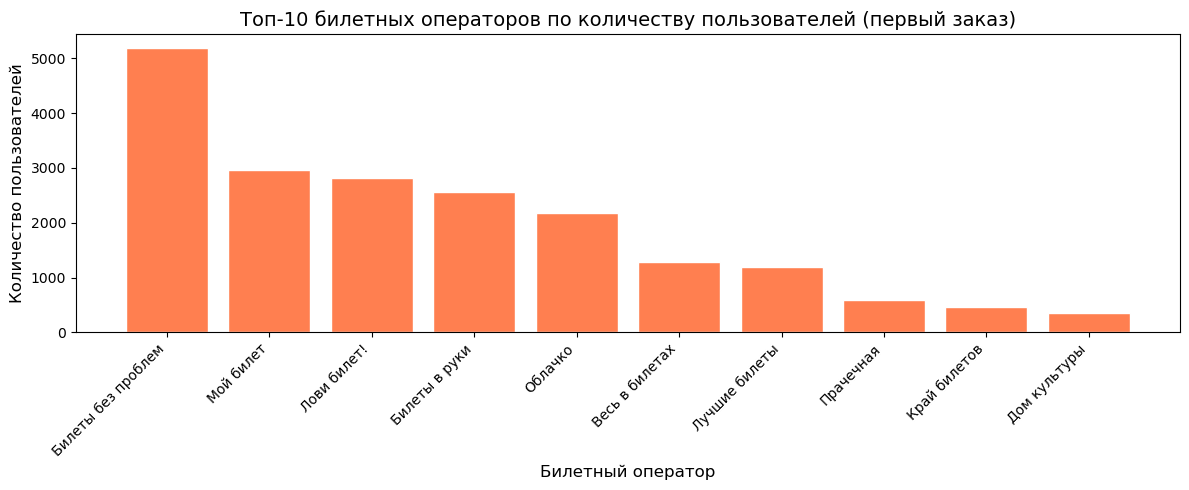

In [141]:
# Билетный оператор (топ-10)
service_stats = segment_stats('first_service_name').head(10)
plt.figure(figsize=(12, 5))
plt.bar(service_stats['first_service_name'], service_stats['users_count'], color='coral', edgecolor='white')
plt.title('Топ-10 билетных операторов по количеству пользователей (первый заказ)', fontsize=14)
plt.xlabel('Билетный оператор', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Выводы — Распределение пользователей по сегментам

- Тип мероприятия
Распределение **неравномерное** — концерты доминируют (~9500 пользователей), 
что почти в 2 раза больше второго по величине сегмента "другое" (~5400).
Театр на третьем месте (~4200). Остальные сегменты (стендап, спорт, выставки, ёлки) 
значительно меньше. **Концерты — явная точка входа на платформу.**

- Тип устройства
Распределение **сильно неравномерное** — mobile (~18000) против desktop (~3500), 
то есть мобильные пользователи составляют около **83% всей аудитории**.
**Mobile — доминирующая точка входа.**

- Регион
Распределение **крайне неравномерное** — Каменевский регион (~7000) и 
Североярская область (~3800) вместе составляют более половины топ-10.
Остальные 8 регионов из топ-10 относительно равны между собой (~400-1200).
**Каменевский регион — ключевая географическая точка входа.**

- Билетный оператор
Распределение **неравномерное**, но менее выраженное чем в регионах — 
"Билеты без проблем" лидирует (~5200), остальные операторы из топ-10 
более равномерны (~300-3000). **"Билеты без проблем" — главная точка входа среди операторов.**

- Общий вывод
Во всех четырёх признаках наблюдаются **явные точки входа** — сегменты с 
наибольшим числом пользователей. Распределение ни по одному признаку не является 
равномерным. Это важно учитывать при сегментации: анализ малых сегментов 
(например, ёлки или desktop) может давать нестабильные результаты из-за малого объёма данных.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [142]:
def retention_stats(col, top_n=None):
    stats = user_profile.groupby(col).agg(
        users_count=('user_id', 'count'),
        returned=('is_two', 'sum')
    ).reset_index()
    stats['return_rate'] = stats['returned'] / stats['users_count']
    stats = stats.sort_values('users_count', ascending=False)
    if top_n:
        stats = stats.head(top_n)
    return stats

In [143]:
avg_return_rate = user_profile['is_two'].mean()
print(f" Средняя доля пользователей с 2 и более заказами = {avg_return_rate:.2f}")

 Средняя доля пользователей с 2 и более заказами = 0.61


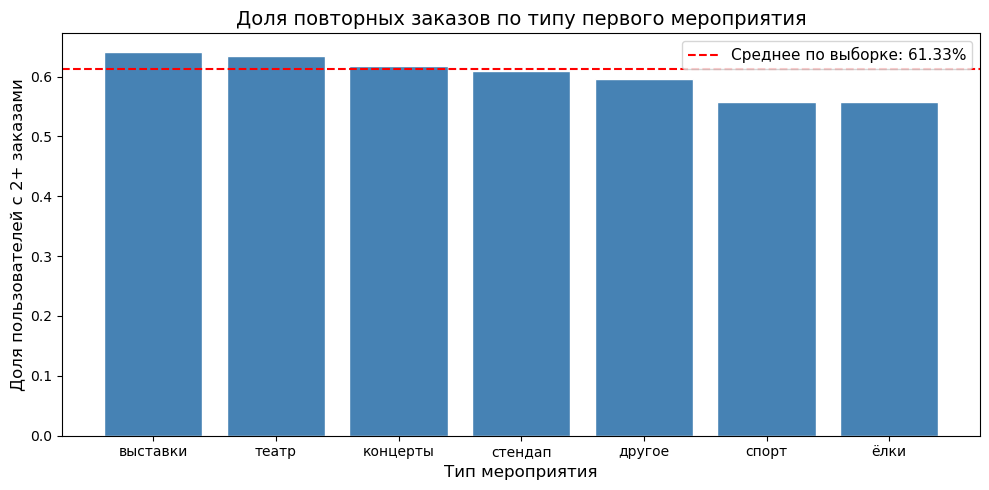

In [144]:
# По типу мероприятия
event_ret = retention_stats('first_event_type').sort_values(by='return_rate', ascending = False)
plt.figure(figsize=(10, 5))
plt.bar(event_ret['first_event_type'], event_ret['return_rate'], color='steelblue', edgecolor='white')
plt.axhline(avg_return_rate, color='red', linestyle='--', label=f'Среднее по выборке: {avg_return_rate:.2%}')
plt.title('Доля повторных заказов по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Доля пользователей с 2+ заказами', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [145]:
print('Тип мероприятия')
display(event_ret[['first_event_type', 'users_count', 'return_rate']])

Тип мероприятия


,first_event_type,users_count,return_rate
0,выставки,414,0.640097
5,театр,4239,0.633876
2,концерты,9560,0.618305
4,стендап,1110,0.609009
1,другое,5426,0.596203
3,спорт,794,0.557935
6,ёлки,95,0.557895


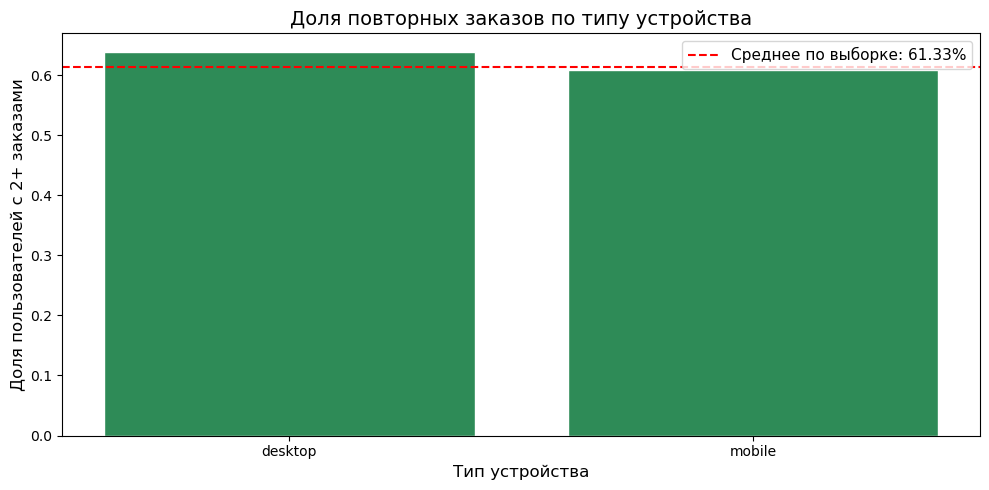

In [146]:
# По типу устройства
device_ret = retention_stats('first_device').sort_values(by='return_rate', ascending = False)

plt.figure(figsize=(10, 5))
plt.bar(device_ret['first_device'], device_ret['return_rate'], color='seagreen', edgecolor='white')
plt.axhline(avg_return_rate, color='red', linestyle='--', label=f'Среднее по выборке: {avg_return_rate:.2%}')
plt.title('Доля повторных заказов по типу устройства', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля пользователей с 2+ заказами', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [147]:
print('Тип устройства')
display(device_ret[['first_device', 'users_count', 'return_rate']])

Тип устройства


,first_device,users_count,return_rate
0,desktop,3714,0.638126
1,mobile,17924,0.608123


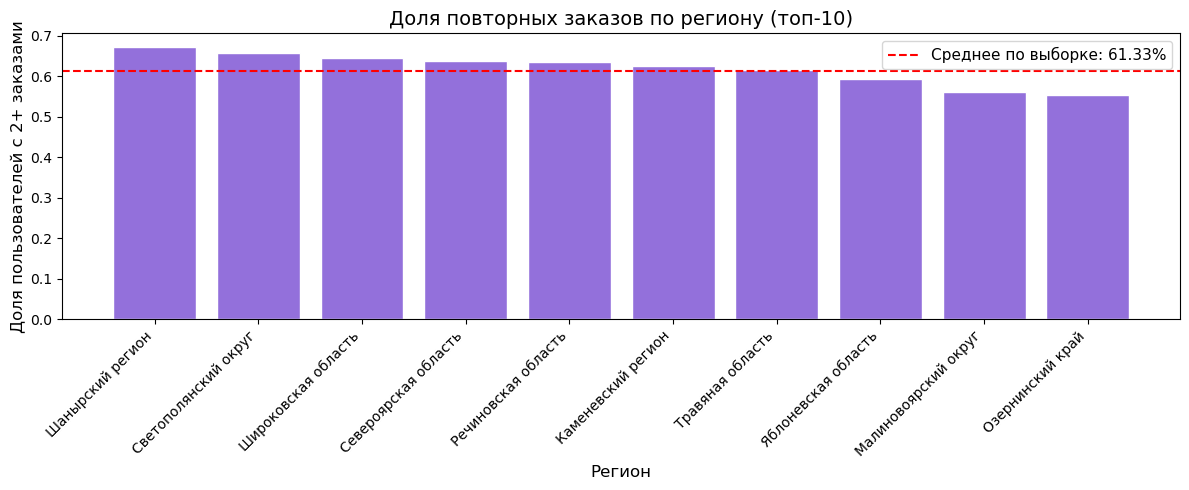

In [148]:
# По региону (топ-10)
region_ret = retention_stats('first_region', top_n=10).sort_values(by='return_rate', ascending = False)

plt.figure(figsize=(12, 5))
plt.bar(region_ret['first_region'], region_ret['return_rate'], color='mediumpurple', edgecolor='white')
plt.axhline(avg_return_rate, color='red', linestyle='--', label=f'Среднее по выборке: {avg_return_rate:.2%}')
plt.title('Доля повторных заказов по региону (топ-10)', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Доля пользователей с 2+ заказами', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [149]:
print('Регион (топ-10)')
display(region_ret[['first_region', 'users_count', 'return_rate']])

Регион (топ-10)


,first_region,users_count,return_rate
76,Шанырский регион,500,0.672000
57,Светополянский округ,457,0.656455
77,Широковская область,1224,0.645425
60,Североярская область,3767,0.638174
52,Речиновская область,440,0.634091
23,Каменевский регион,7085,0.623994
74,Травяная область,488,0.614754
78,Яблоневская область,411,0.593674
41,Малиновоярский округ,525,0.560000
45,Озернинский край,675,0.552593


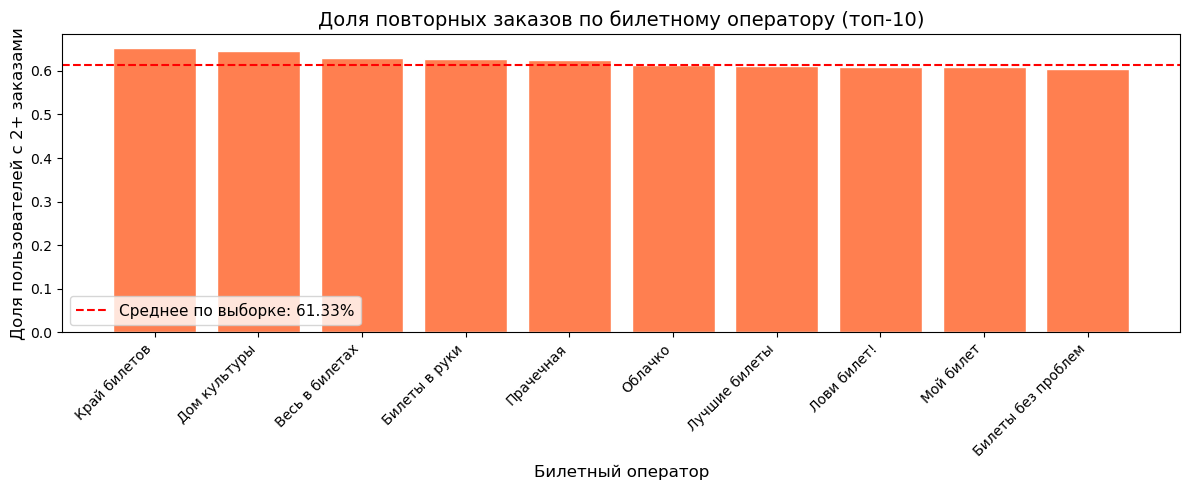

In [150]:
# По билетному оператору (топ-10)
service_ret = retention_stats('first_service_name', top_n=10).sort_values(by='return_rate', ascending = False)

plt.figure(figsize=(12, 5))
plt.bar(service_ret['first_service_name'], service_ret['return_rate'], color='coral', edgecolor='white')
plt.axhline(avg_return_rate, color='red', linestyle='--', label=f'Среднее по выборке: {avg_return_rate:.2%}')
plt.title('Доля повторных заказов по билетному оператору (топ-10)', fontsize=14)
plt.xlabel('Билетный оператор', fontsize=12)
plt.ylabel('Доля пользователей с 2+ заказами', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [151]:
print('Билетный оператор (топ-10)')
display(service_ret[['first_service_name', 'users_count', 'return_rate']])

Билетный оператор (топ-10)


,first_service_name,users_count,return_rate
17,Край билетов,454,0.651982
12,Дом культуры,356,0.646067
7,Весь в билетах,1285,0.628794
4,Билеты в руки,2559,0.627198
24,Прачечная,583,0.626072
23,Облачко,2177,0.612770
20,Лучшие билеты,1184,0.612331
19,Лови билет!,2809,0.609114
22,Мой билет,2969,0.608622
3,Билеты без проблем,5186,0.604126


##### Выводы — Доля повторных заказов по сегментам

Среднее по выборке: **61.33%**

Тип мероприятия
Все сегменты находятся в диапазоне 55–64%, однако размеры сильно различаются:
- **Концерты** (9560 польз.) и **другое** (5426 польз.) — крупнейшие сегменты,
  результаты статистически надёжны. Концерты на уровне среднего (61.8%),
  другое — чуть ниже (59.6%)
- **Театр** (4239 польз., 63.4%) — выше среднего, достаточный объём
- **Стендап** (1110 польз., 60.9%) — на уровне среднего
- **Спорт** (794 польз., 55.8%) и **выставки** (414 польз., 64.0%) — 
  объём небольшой, интерпретировать с осторожностью
- **Ёлки** (95 польз., 55.8%) — слишком мало пользователей, 
  результат ненадёжен и не может служить основой для выводов

Тип устройства
- **Mobile** (17924 польз., 60.8%) — доминирующий сегмент, 83% всех пользователей
- **Desktop** (3714 польз., 63.8%) — в 5 раз меньше пользователей

Несмотря на то что desktop показывает чуть более высокий возврат,
сегменты **сильно несбалансированы** по размеру. Тип устройства
слабо влияет на возврат пользователей.

Регион (топ-10)
Топ-10 регионов **крайне несбалансированы** по размеру:
- **Каменевский регион** (7085 польз., 62.4%) и **Североярская область** 
  (3767 польз., 63.8%) — вместе составляют ~76% топ-10, 
  их результаты статистически надёжны и близки к среднему
- Остальные 8 регионов (411–1224 польз.) — в 3–17 раз меньше лидера,
  их доли возврата (55–67%) менее стабильны
- **Шанырский регион** (500 польз., 67.2%) выглядит лидером по возврату,
  но малый объём не позволяет делать уверенные выводы

Билетный оператор (топ-10)
- **Билеты без проблем** (5186 польз., 60.4%) — крупнейший оператор,
  результат надёжен, чуть ниже среднего
- **Мой билет** (2969 польз.), **Лови билет!** (2809 польз.), 
  **Билеты в руки** (2559 польз.) — достаточный объём, возврат 60–63%
- **Край билетов** (454 польз., 65.2%) и **Дом культуры** (356 польз., 64.6%) —
  показывают высокий возврат, но объём мал — интерпретировать с осторожностью

Общий вывод
- Ни один признак первого заказа не даёт **выраженного преимущества** по возврату —
все крупные и статистически надёжные сегменты держатся в диапазоне 60–64%.
Признаки с малым числом пользователей (ёлки, часть регионов, мелкие операторы)
показывают более широкий разброс, но их результаты **не следует считать достоверными**.
Тип мероприятия, устройство, регион и билетный оператор слабо влияют на 
вероятность повторного заказа.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [152]:
## Проверяем гипотезу 1
sport = event_ret[event_ret['first_event_type'] == 'спорт']['return_rate'].values[0]
concerts = event_ret[event_ret['first_event_type'] == 'концерты']['return_rate'].values[0]
print(f'Спорт: {sport:.2%}')
print(f'Концерты: {concerts:.2%}')
print(f'Среднее по выборке: {avg_return_rate:.2%}')

Спорт: 55.79%
Концерты: 61.83%
Среднее по выборке: 61.33%


In [153]:
display(region_ret[['first_region', 'users_count', 'return_rate']])

,first_region,users_count,return_rate
76,Шанырский регион,500,0.672000
57,Светополянский округ,457,0.656455
77,Широковская область,1224,0.645425
60,Североярская область,3767,0.638174
52,Речиновская область,440,0.634091
23,Каменевский регион,7085,0.623994
74,Травяная область,488,0.614754
78,Яблоневская область,411,0.593674
41,Малиновоярский округ,525,0.560000
45,Озернинский край,675,0.552593


##### Выводы по задаче — Проверка гипотез

Гипотеза 1: Спорт vs Концерты
- Спорт: **55.79%**
- Концерты: **61.83%**
- Среднее по выборке: **61.33%**

**Гипотеза не подтвердилась.** Пользователи, чей первый заказ был на спортивное 
мероприятие, возвращаются **реже** чем те, кто начал с концертов (55.79% vs 61.83%).
Более того, спорт — один из худших сегментов по возврату, ниже среднего по выборке.
При этом важно учитывать что сегмент спорта (794 польз.) значительно меньше 
концертов (9560 польз.) — это снижает надёжность сравнения.

Гипотеза 2: Активные регионы vs менее активные
Два крупнейших региона с наибольшим числом пользователей:
- **Каменевский регион** (7085 польз.) — 62.4%
- **Североярская область** (3767 польз.) — 63.8%

Оба выше среднего, однако среди менее активных регионов есть 
как более высокие (Шанырский регион — 67.2%), 
так и более низкие (Озернинский край — 55.3%) показатели возврата.

**Гипотеза частично подтвердилась** — крупнейшие регионы действительно 
показывают возврат выше среднего, но однозначной закономерности нет: 
размер региона не гарантирует высокий возврат. Малые регионы дают 
нестабильные результаты из-за небольшого числа пользователей.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [154]:
import seaborn as sns

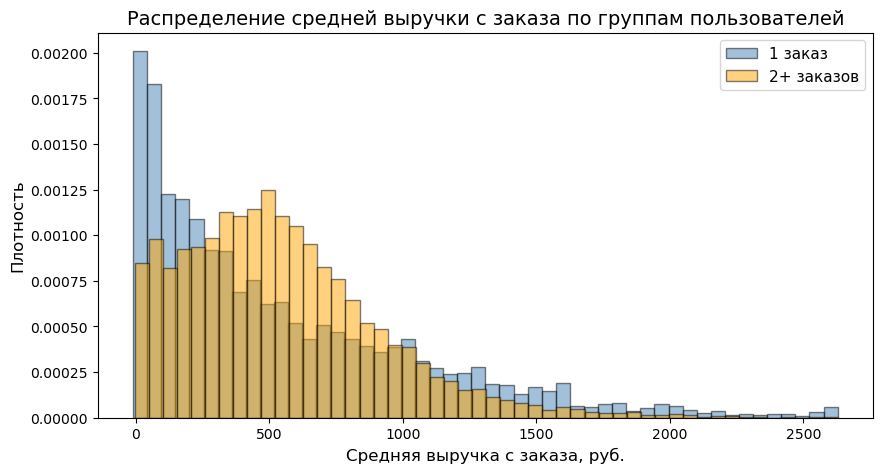

In [155]:
group_two = user_profile[user_profile['is_two'] == True]['mean_rub_revenue']
group_not_two = user_profile[user_profile['is_two'] == False]['mean_rub_revenue']

plt.figure(figsize=(10, 5))
plt.hist(group_not_two, bins=50, density=True, alpha=0.5, color='steelblue', label='1 заказ', edgecolor = 'black')
plt.hist(group_two, bins=50, density=True, alpha=0.5, color='orange', label='2+ заказов',edgecolor = 'black')
plt.title('Распределение средней выручки с заказа по группам пользователей', fontsize=14)
plt.ylabel('Плотность', fontsize=12)
plt.xlabel('Средняя выручка с заказа, руб.', fontsize=12)
plt.legend(fontsize=11)
plt.show()

##### Выводы - Средняя выручка и повторные заказы

Наблюдения по графику

**Пользователи с 1 заказом (False, синий):**
- Резкий пик в диапазоне 0–100 руб. — большая концентрация пользователей 
  с очень низкой выручкой
- Быстро убывает после 200 руб.
- Практически отсутствуют в диапазоне 500–2500 руб.

**Пользователи с 2+ заказами (True, оранжевый):**
- Пик смещён вправо — концентрация в диапазоне 300–700 руб.
- Распределение более равномерное и широкое

Есть ли различия?
Да, различия **выражены**:
- Пользователи с одним заказом тяготеют к **низкой выручке (0–200 руб.)**
- Вернувшиеся пользователи тяготеют к **средней выручке (300–700 руб.)**
- Это говорит о том, что **более высокая средняя выручка с заказа 
  связана с большей вероятностью повторной покупки** — 
  пользователи готовые тратить больше более лояльны к платформе

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


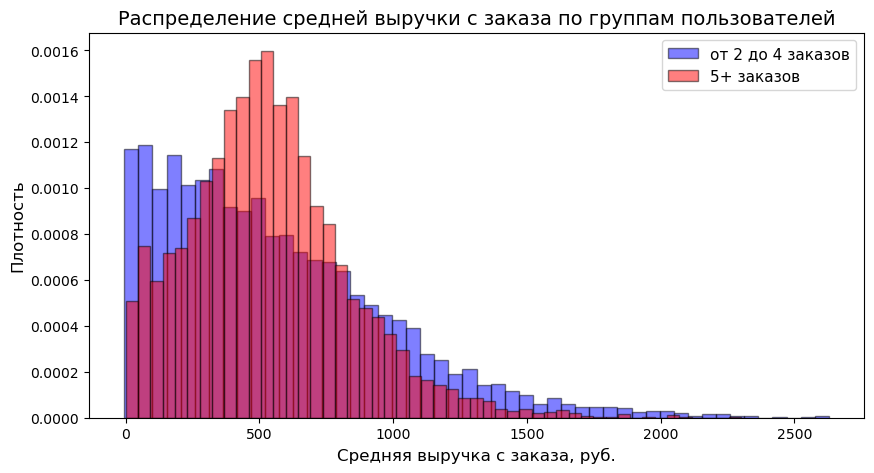

In [156]:
group_five = user_profile[user_profile['is_five'] == True]['mean_rub_revenue']
group_not_five = user_profile[(user_profile['is_five'] == False) & (user_profile['is_two'] == True)]['mean_rub_revenue']

plt.figure(figsize=(10, 5))
plt.hist(group_not_five, bins=50, density=True, alpha=0.5, color='blue', label='от 2 до 4 заказов',  edgecolor='black')
plt.hist(group_five, bins=50, density=True, alpha=0.5, color='red', label='5+ заказов',  edgecolor='black')
plt.title('Распределение средней выручки с заказа по группам пользователей', fontsize=14)
plt.ylabel('Плотность', fontsize=12)
plt.xlabel('Средняя выручка с заказа, руб.', fontsize=12)
plt.legend(fontsize=11)
plt.show()

##### Выводы Средняя выручка: 2–4 заказа vs 5+ заказов

**Группа 2–4 заказа (синий):**
- Пик в диапазоне 0–200 руб. — заметная концентрация пользователей с низкой выручкой
- Распределение более широкое и плавно убывает вплоть до 2500+ руб.

**Группа 5+ заказов (красный):**
- Пик смещён вправо — концентрация в диапазоне 400–600 руб.
- Практически отсутствуют в диапазоне 0–100 руб.
- Распределение более узкое и обрывается после 1000 руб.

Различия также **выражены**:
- Наиболее лояльные пользователи (5+ заказов) тратят **больше за один заказ** — 
  их пик приходится на 400–600 руб., тогда как у группы 2–4 заказа пик в районе 0–200 руб.
- Пользователи с очень низкой выручкой (0–100 руб.) практически не встречаются 
  среди тех кто совершил 5+ заказов
- **Вывод:** более высокая средняя выручка с заказа связана с более высокой 
  лояльностью пользователей — чем больше пользователь тратит, 
  тем чаще он возвращается на платформу

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [157]:
bins = [0,2,3,5,float('inf') ]
labels = ['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов']
user_profile['tickets_segment'] = pd.cut(user_profile['mean_tickets_number'], bins = bins, labels=labels)


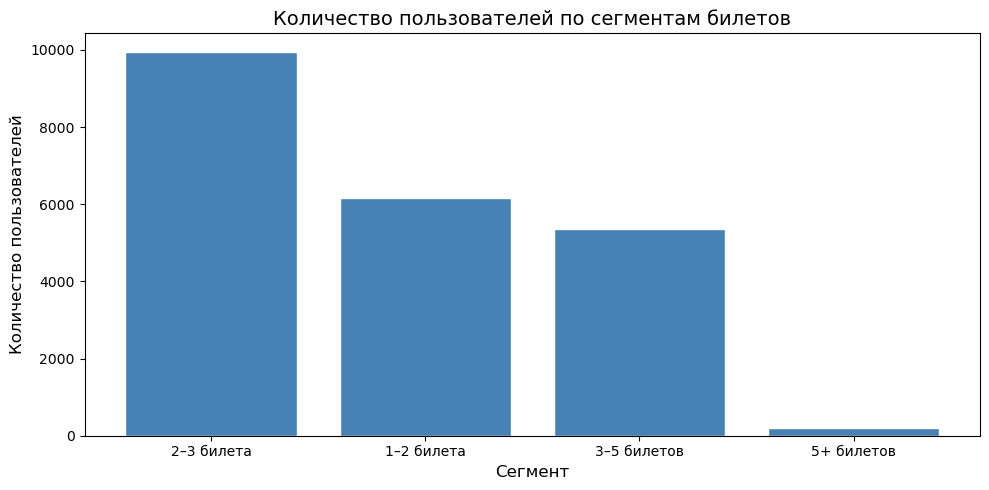

In [158]:
# Статистика по сегментам
tickets_stats = user_profile.groupby('tickets_segment', observed=True).agg(
    users_count=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index().sort_values(by='users_count', ascending = False)

# Количество пользователей по сегментам
plt.figure(figsize=(10, 5))
plt.bar(tickets_stats['tickets_segment'], tickets_stats['users_count'], 
        color='steelblue', edgecolor='white')
plt.title('Количество пользователей по сегментам билетов', fontsize=14)
plt.xlabel('Сегмент', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.tight_layout()
plt.show()

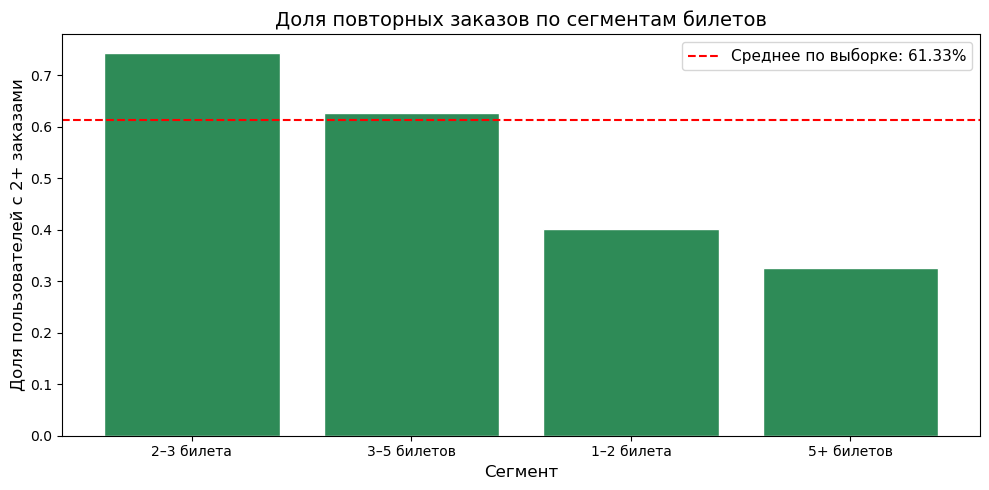

In [159]:
# Доля повторных заказов по сегментам
avg_return_rate = user_profile['is_two'].mean()
tickets_stats = tickets_stats.sort_values(by = 'return_rate', ascending= False)
plt.figure(figsize=(10, 5))
plt.bar(tickets_stats['tickets_segment'], tickets_stats['return_rate'], 
        color='seagreen', edgecolor='white')
plt.axhline(avg_return_rate, color='red', linestyle='--', 
            label=f'Среднее по выборке: {avg_return_rate:.2%}')
plt.title('Доля повторных заказов по сегментам билетов', fontsize=14)
plt.xlabel('Сегмент', fontsize=12)
plt.ylabel('Доля пользователей с 2+ заказами', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [160]:
display(tickets_stats)

,tickets_segment,users_count,return_rate
1,2–3 билета,9935,0.742828
2,3–5 билетов,5349,0.627033
0,1–2 билета,6160,0.401461
3,5+ билетов,194,0.324742


##### Выводы — Количество билетов и повторные заказы

Распределение по сегментам
Пользователи распределены **неравномерно**:
- **2–3 билета** (9935 польз.) — самый крупный сегмент, почти половина всех пользователей
- **1–2 билета** (6160 польз.) — второй по размеру
- **3–5 билетов** (5349 польз.) — третий
- **5+ билетов** (194 польз.) — очень маленький сегмент, результаты ненадёжны

Большинство пользователей покупают **2–3 билета** за заказ — 
типичный сценарий похода.

Доля повторных заказов по сегментам
Среднее по выборке: **61.33%**

Наблюдается нелинейная зависимость:
- **1–2 билета** (40.1%) — значительно ниже среднего
- **2–3 билета** (74.3%) — **аномально высокий** показатель, сильно выше среднего
- **3–5 билетов** (62.7%) — на уровне среднего
- **5+ билетов** (32.5%) — аномально низкий, но сегмент слишком мал (194 польз.)
  для достоверных выводов

### Общий вывод
Сегмент **2–3 билета** выделяется как по объёму так и по лояльности — 
пользователи покупающие 2–3 билета возвращаются значительно чаще.
Покупка одиночного или очень большого количества билетов 
напротив связана с низкой вероятностью повторного заказа.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [161]:
user_profile['day_of_week'] = user_profile['first_order_dt'].dt.day_of_week

In [162]:
display(user_profile)

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service_name,first_event_type,total_orders,mean_rub_revenue,mean_tickets_number,avg_days_since_prev,is_two,is_five,tickets_segment,day_of_week
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False,3–5 билетов,1
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.000,True,False,2–3 билета,1
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.000,True,False,2–3 билета,5
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False,3–5 билетов,3
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.000,True,False,1–2 билета,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21849,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13.375,True,True,2–3 билета,1
21850,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74.000,True,False,2–3 билета,3
21851,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4.125,True,True,2–3 билета,3
21852,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaN,False,False,1–2 билета,1


In [163]:
day_of_week_distribution = user_profile.groupby('day_of_week', as_index= False).agg(users_count = ('user_id', 'count'), return_rate = ('is_two','mean'))
day_of_week_distribution['day_of_week'] = ['Понедельник','Вторник','Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
day_of_week_distribution

,day_of_week,users_count,return_rate
0,Понедельник,2930,0.630375
1,Вторник,3176,0.619018
2,Среда,3057,0.621851
3,Четверг,3113,0.594282
4,Пятница,3259,0.598343
5,Суббота,3326,0.628082
6,Воскресенье,2777,0.600288


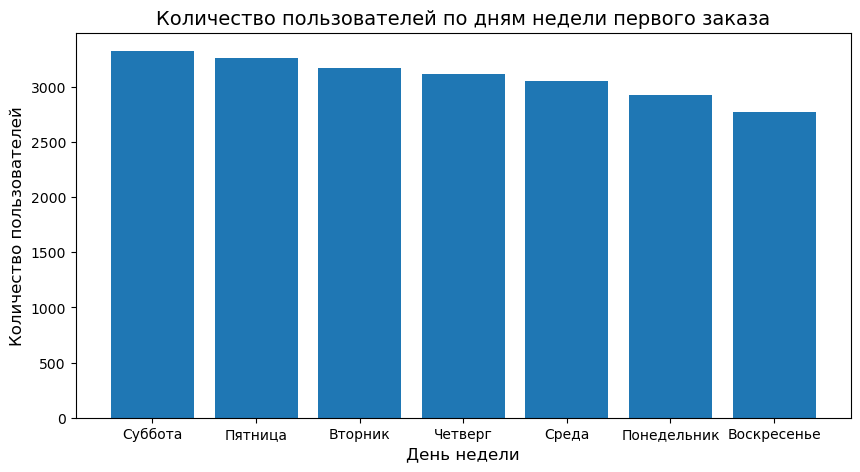

In [164]:
## Cтолбчатая диаграмма количества пользователей
day_of_week_distribution = day_of_week_distribution.sort_values(by='users_count', ascending=False)
plt.figure(figsize=(10,5))
plt.bar(day_of_week_distribution['day_of_week'], day_of_week_distribution['users_count'])
plt.xlabel('День недели', fontsize = 12)
plt.ylabel('Количество пользователей',fontsize = 12)
plt.title('Количество пользователей по дням недели первого заказа', fontsize = 14)
plt.show()


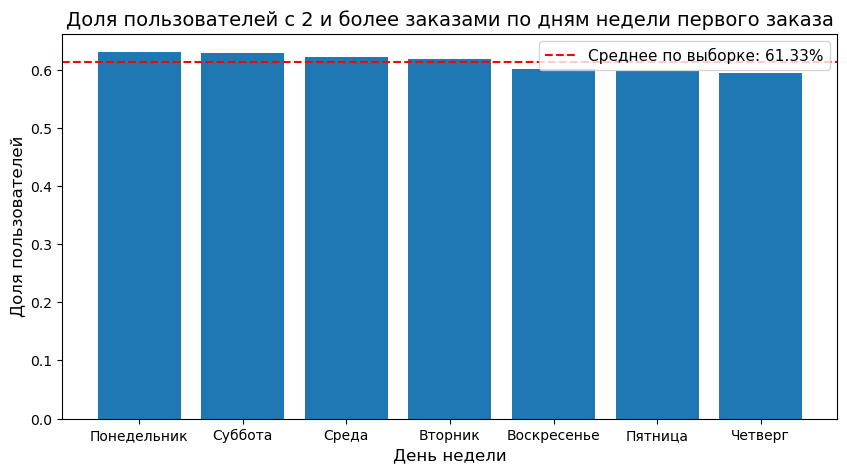

In [165]:
## Столбчатая диаграмма доли вернувшихся пользователей
day_of_week_distribution = day_of_week_distribution.sort_values(by='return_rate', ascending=False)
plt.figure(figsize=(10,5))
plt.bar(day_of_week_distribution['day_of_week'], day_of_week_distribution['return_rate'])
plt.xlabel('День недели', fontsize = 12)
plt.ylabel('Доля пользователей',fontsize = 12)
plt.title('Доля пользователей с 2 и более заказами по дням недели первого заказа', fontsize = 14)
plt.axhline(avg_return_rate, color='red', linestyle='--', 
            label=f'Среднее по выборке: {avg_return_rate:.2%}')
plt.legend(fontsize=11)
plt.show()


##### Выводы по задаче 4.3.1 — День недели первого заказа

**Распределение пользователей по дням недели**

Распределение **равномерное** — количество новых пользователей 
примерно одинаково во все дни недели (2750–3300 польз.).
Небольшой пик в пятницу и субботу, минимум в воскресенье — 
но разница незначительная.

**Доля повторных заказов по дням недели**

Все дни находятся в диапазоне **59–63%** — очень близко к среднему по выборке (61.33%).
- Понедельник (~63%) и суббота (~63%) — чуть выше среднего
- Четверг (~60%) и пятница (~60%) — чуть ниже среднего

**Вывод**

День недели первого заказа **практически не влияет** на вероятность 
возврата пользователя — разброс между днями составляет всего ~4 процентных пункта.
Значимых точек входа по дням недели не обнаружено.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Среднее время между заказами (2–4 заказа): 21.3 дней
Среднее время между заказами (5+ заказов): 9.9 дней


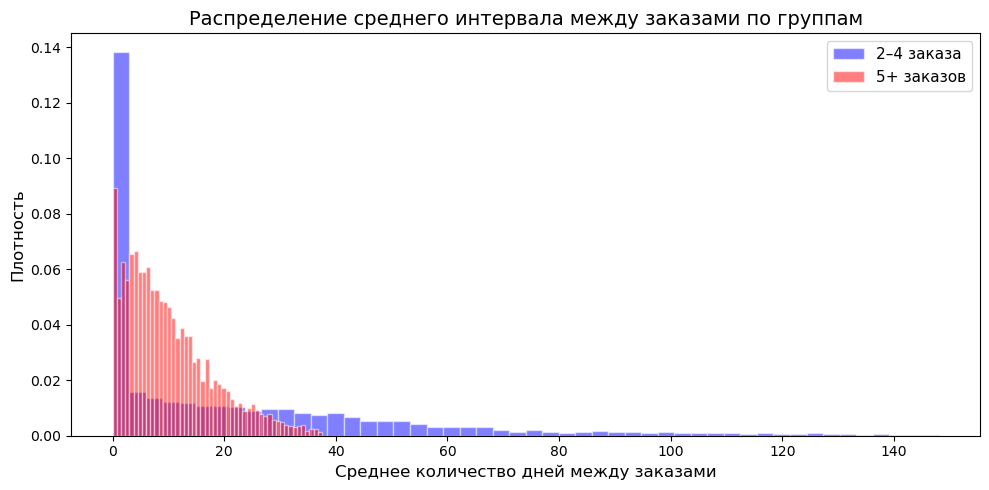

In [166]:
group_2_4 = user_profile[(user_profile['is_five'] == False) & (user_profile['is_two'] == True)]['avg_days_since_prev']
group_5_plus = user_profile[user_profile['is_five'] == True]['avg_days_since_prev']

print(f'Среднее время между заказами (2–4 заказа): {group_2_4.mean():.1f} дней')
print(f'Среднее время между заказами (5+ заказов): {group_5_plus.mean():.1f} дней')

# Гистограмма
plt.figure(figsize=(10, 5))
plt.hist(group_2_4, bins=50, density=True, alpha=0.5, color='blue', label='2–4 заказа', edgecolor = 'white')
plt.hist(group_5_plus, bins=50, density=True, alpha=0.5, color='red', label='5+ заказов', edgecolor = 'white')
plt.title('Распределение среднего интервала между заказами по группам', fontsize=14)
plt.xlabel('Среднее количество дней между заказами', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

##### Выводы — Интервал между заказами и удержание клиентов

- **2–4 заказа:** среднее 21.3 дня между заказами
- **5+ заказов:** среднее 9.9 дня между заказами — **в 2 раза меньше**

###### Наблюдения по графику
**Группа 2–4 заказа:**
- Пик в районе 0–2 дней, но распределение широкое — 
  пользователи возвращаются в очень разные сроки
- Длинный хвост вплоть до 140+ дней — есть пользователи 
  которые возвращаются очень редко

**Группа 5+ заказов:**
- Пик также в районе 0–2 дней, но распределение 
  **значительно более сжатое** — обрывается около 40 дней
- Практически нет пользователей с интервалом более 40 дней

### Вывод
Между интервалом заказов и лояльностью есть **чёткая связь** — наиболее лояльные пользователи (5+ заказов) возвращаются вдвое быстрее чем менее активные (2–4 заказа). Чем короче интервал между покупками, тем выше вероятность что пользователь останется на платформе надолго.Пользователи с большими интервалами (40+ дней) практически не входят в группу высоколояльных.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [167]:
from phik import phik_matrix

In [168]:
cols = ['first_event_type', 'first_device', 'first_region', 
        'first_service_name', 'mean_rub_revenue', 'mean_tickets_number',
        'avg_days_since_prev', 'day_of_week', 'total_orders']


phik_corr = user_profile[cols].phik_matrix(interval_cols=['mean_rub_revenue', 
                                                           'mean_tickets_number',
                                                           'avg_days_since_prev',
                                                           'total_orders'])


In [169]:
phik_corr_total_orders = phik_corr[['total_orders']].drop('total_orders').sort_values(by = 'total_orders',ascending = False)
phik_corr_total_orders

,total_orders
avg_days_since_prev,0.283791
mean_tickets_number,0.225904
mean_rub_revenue,0.219482
first_region,0.113663
day_of_week,0.060831
first_event_type,0.027745
first_service_name,0.027483
first_device,0.025945


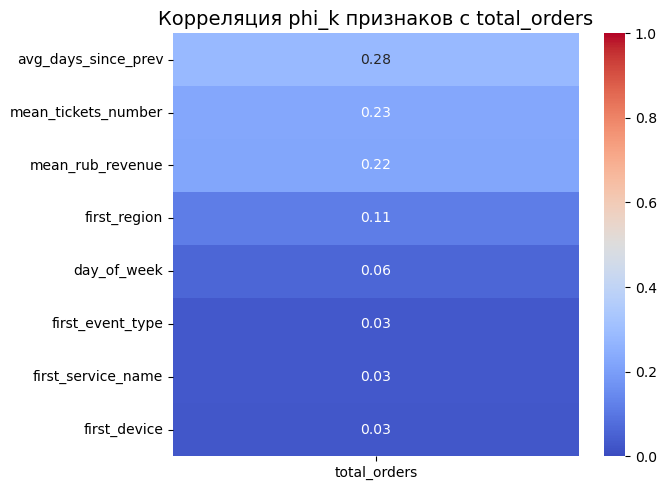

In [170]:
plt.figure(figsize=(7,5))
sns.heatmap(phik_corr_total_orders, vmin=0,vmax=1,cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Корреляция phi_k признаков с total_orders', fontsize=14)
plt.tight_layout()
plt.show()

In [171]:
user_profile['total_orders'].value_counts().head(10)

total_orders
1     8368
2     3572
3     2175
4     1400
5      971
6      700
7      542
8      455
9      384
10     291
Name: count, dtype: int64

**Вывод: большинство пользователей имеют только один заказ, поэтому корреляция считается некорректно.Требуется разделить на сегменты**

In [172]:
user_profile['order_segment'] = pd.cut(
    user_profile['total_orders'],
    bins=[0, 1, 4, float('inf')],
    labels=['1 заказ', '2–4 заказа', '5+ заказов']
)

In [173]:
phik_corr_segment = user_profile[cols + ['order_segment']].drop(columns='total_orders').phik_matrix(
    interval_cols=['mean_rub_revenue', 'mean_tickets_number', 'avg_days_since_prev']
)

In [174]:
phik_corr_segment[['order_segment']].drop('order_segment')

,order_segment
first_event_type,0.040322
first_device,0.017110
first_region,0.123473
first_service_name,0.081308
mean_rub_revenue,0.326091
mean_tickets_number,0.383366
avg_days_since_prev,0.390127
day_of_week,0.034267


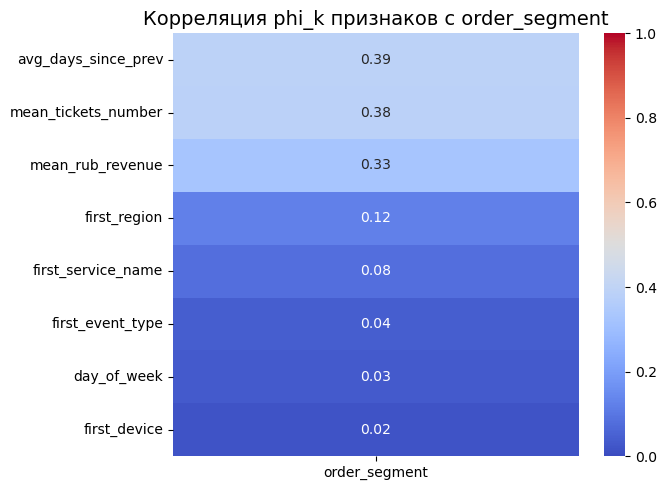

In [175]:
plt.figure(figsize=(7,5))
sns.heatmap(phik_corr_segment[['order_segment']].drop('order_segment').sort_values(by = 'order_segment',ascending = False), vmin=0,vmax=1,cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Корреляция phi_k признаков с order_segment', fontsize=14)
plt.tight_layout()
plt.show()

##### Выводы по задаче 4.4.1 — Корреляционный анализ phi_k

**Почему использовали order_segment вместо total_orders**
В `total_orders` большинство пользователей имеют 1–2 заказа — 
преобладание одного значения подавляет корреляцию и даёт результаты близкие к нулю.
После разбивки на сегменты (1 заказ / 2–4 заказа / 5+ заказов) 
корреляции стали более выраженными.

##### Результаты корреляции с order_segment

**Наиболее связанные признаки:**
- `avg_days_since_prev` (0.39) — **сильнейшая связь**: чем короче интервал 
  между заказами, тем выше сегмент лояльности
- `mean_tickets_number` (0.38) — количество билетов в заказе 
  тесно связано с числом заказов
- `mean_rub_revenue` (0.33) — выручка с заказа также значимо связана 
  с лояльностью пользователя

**Умеренная связь:**
- `first_region` (0.12) — регион первого заказа слабо но заметно влияет

**Слабая или отсутствующая связь:**
- `first_service_name` (0.08), `first_event_type` (0.04), 
  `day_of_week` (0.03), `first_device` (0.02) — 
  практически не связаны с количеством заказов

##### Общий вывод
Количество заказов пользователя наиболее тесно связано с 
**поведенческими характеристиками** — интервалом между покупками, 
количеством билетов и выручкой с заказа. 
Характеристики первого заказа (тип события, устройство, сервис, день недели) 
**практически не влияют** на то сколько заказов совершит пользователь.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**